# Workshop 2 — Neural Network (MLP) for Image Classification (Conceptual)
We keep the **same dataset** (Fashion-MNIST) and upgrade the model:

**Logistic regression** → **MLP** (hidden layers + ReLU)

**Learning goals**
- See why **nonlinearity** helps
- Observe **overfitting** and control it with **dropout / L2 / early stopping**


In [1]:
# If needed (most environments already have these)
# !pip -q install tensorflow matplotlib numpy

import os, math, time, random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.20.0
GPU available: False


In [2]:
def show_images(images, labels=None, class_names=None, n=12, cols=6, title=None):
    plt.figure(figsize=(cols*2, math.ceil(n/cols)*2))
    for i in range(n):
        ax = plt.subplot(math.ceil(n/cols), cols, i+1)
        plt.imshow(images[i], cmap="gray")
        if labels is not None:
            lab = int(labels[i])
            if class_names is not None:
                plt.title(class_names[lab], fontsize=9)
            else:
                plt.title(str(lab), fontsize=9)
        plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

def plot_history(hist, metrics=("accuracy",), title="Training curves"):
    plt.figure(figsize=(7,4))
    for m in metrics:
        plt.plot(hist.history[m], label=f"train_{m}")
        val_key = "val_" + m
        if val_key in hist.history:
            plt.plot(hist.history[val_key], label=f"val_{m}")
    if "loss" in hist.history:
        plt.plot(hist.history["loss"], label="train_loss", linestyle="--")
        if "val_loss" in hist.history:
            plt.plot(hist.history["val_loss"], label="val_loss", linestyle="--")
    plt.title(title)
    plt.xlabel("epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


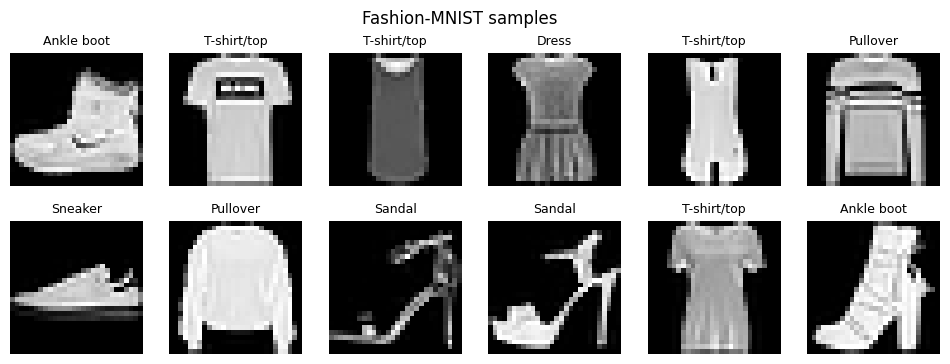

In [3]:
# Dataset: Fashion-MNIST (28x28 grayscale, 10 classes)
# - downloads automatically on first run
# - small enough for CPU, but still benefits from CNN
# - good to illustrate: linear vs MLP vs CNN

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

show_images(x_train[:12], y_train[:12], class_names, title="Fashion-MNIST samples")


In [4]:
# Split: train -> train/val, then keep test unseen
# Normalize pixel values to [0, 1]

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Create validation set (10k from training)
val_size = 10000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr,  y_tr  = x_train[:-val_size], y_train[:-val_size]

print("Train:", x_tr.shape, "Val:", x_val.shape, "Test:", x_test.shape)


Train: (50000, 28, 28) Val: (10000, 28, 28) Test: (10000, 28, 28)


## 1) Build an MLP
Try changing hidden size and depth. Watch overfitting.

In [5]:
# Hyperparameters to play with
LEARNING_RATE = 1e-3
BATCH_SIZE    = 128
EPOCHS        = 20

HIDDEN_UNITS  = 256
DROPOUT       = 0.3          # set 0.0 to disable
L2_WEIGHT     = 1e-4         # set 0.0 to disable

regularizer = keras.regularizers.l2(L2_WEIGHT) if L2_WEIGHT > 0 else None

model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(HIDDEN_UNITS, activation="relu", kernel_regularizer=regularizer),
    layers.Dropout(DROPOUT),
    layers.Dense(HIDDEN_UNITS//2, activation="relu", kernel_regularizer=regularizer),
    layers.Dropout(DROPOUT),
    layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 2) Train with monitoring
Early stopping = regularization (stops before memorizing noise).

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7686 - loss: 0.7043 - val_accuracy: 0.8374 - val_loss: 0.4930
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8393 - loss: 0.4973 - val_accuracy: 0.8543 - val_loss: 0.4518
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8523 - loss: 0.4607 - val_accuracy: 0.8646 - val_loss: 0.4220
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8609 - loss: 0.4379 - val_accuracy: 0.8626 - val_loss: 0.4212
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8652 - loss: 0.4241 - val_accuracy: 0.8735 - val_loss: 0.4047
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8703 - loss: 0.4103 - val_accuracy: 0.8730 - val_loss: 0.4060
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8743 - loss: 0.4015 - val_accuracy: 0.8794 - val_loss: 0.3848
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8740 - loss: 0.3974 - val_accuracy: 0.

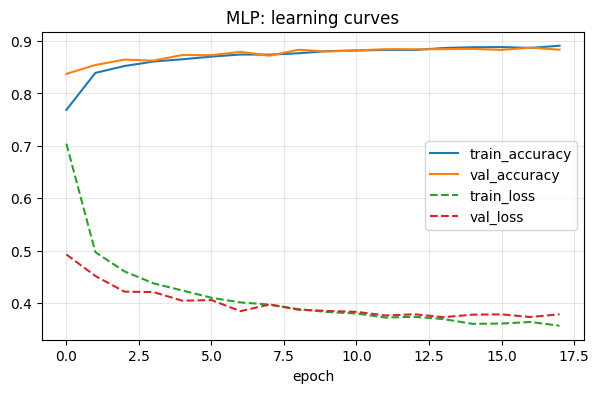

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

hist = model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

plot_history(hist, metrics=("accuracy",), title="MLP: learning curves")


In [7]:
def evaluate_and_report(model, x, y, name="set"):
    loss, acc = model.evaluate(x, y, verbose=0)
    print(f"{name:>5s}  loss={loss:.4f}  acc={acc:.4f}")
    return loss, acc

def confusion_matrix(model, x, y, class_names=None):
    y_prob = model.predict(x, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    cm = tf.math.confusion_matrix(y, y_pred, num_classes=y_prob.shape[1]).numpy()
    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    if class_names is not None:
        plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right", fontsize=8)
        plt.yticks(range(len(class_names)), class_names, fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm


## 3) Evaluate + error analysis

train  loss=0.3126  acc=0.9045
  val  loss=0.3733  acc=0.8846
 test  loss=0.3976  acc=0.8782


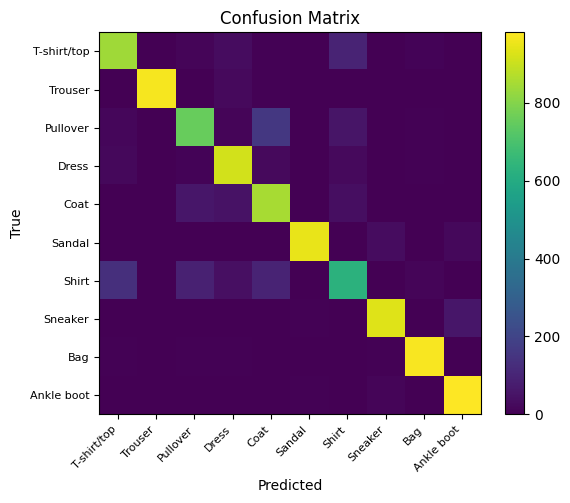

array([[841,   1,  13,  32,   5,   1,  96,   0,  11,   0],
       [  2, 967,   0,  23,   4,   0,   2,   0,   1,   1],
       [ 19,   0, 751,  13, 158,   0,  55,   0,   4,   0],
       [ 22,   2,  10, 912,  26,   0,  23,   0,   4,   1],
       [  0,   1,  61,  47, 852,   0,  36,   0,   3,   0],
       [  0,   0,   0,   0,   0, 946,   0,  32,   1,  21],
       [132,   1,  89,  39,  96,   0, 628,   0,  15,   0],
       [  0,   0,   0,   0,   0,   7,   0, 934,   0,  59],
       [  4,   0,   7,   4,   3,   1,   3,   7, 971,   0],
       [  0,   0,   0,   0,   0,   6,   1,  13,   0, 980]], dtype=int32)

In [8]:
evaluate_and_report(model, x_tr,  y_tr,  "train")
evaluate_and_report(model, x_val, y_val, "val")
evaluate_and_report(model, x_test,y_test,"test")

confusion_matrix(model, x_test, y_test, class_names=class_names)


Shape: (784, 256)


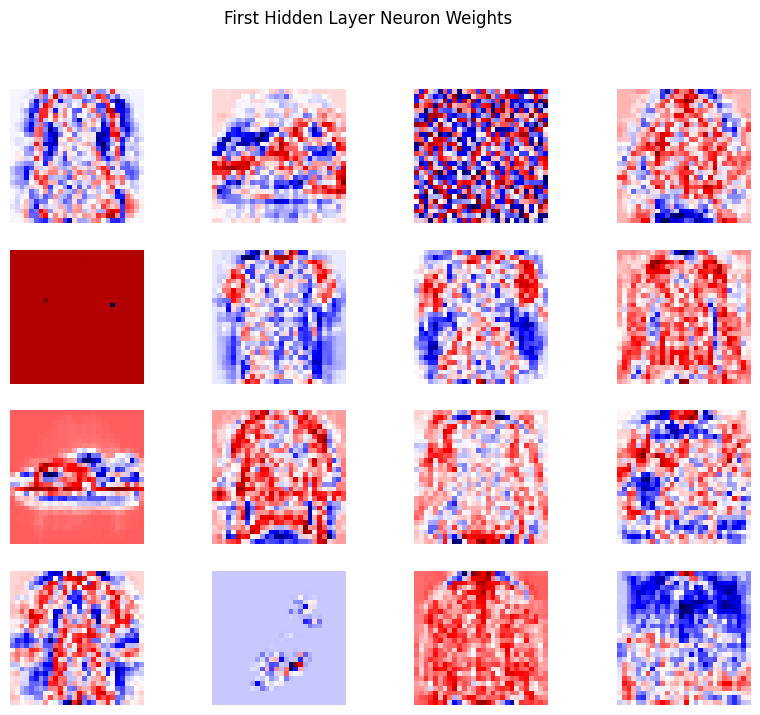

In [10]:
# First Dense layer (after Flatten)
W1, b1 = model.layers[1].get_weights()

print("Shape:", W1.shape)  # (784, 256)

W1_images = W1.reshape(28, 28, -1)

plt.figure(figsize=(10,8))
for i in range(16):  # show first 16 neurons
    plt.subplot(4,4,i+1)
    plt.imshow(W1_images[:,:,i], cmap="seismic")
    plt.axis("off")

plt.suptitle("First Hidden Layer Neuron Weights")
plt.show()

In [11]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

0 flatten Flatten
1 dense Dense
2 dropout Dropout
3 dense_1 Dense
4 dropout_1 Dropout
5 dense_2 Dense


In [12]:
dense_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dense)]

print("Dense layers found:", len(dense_layers))

Dense layers found: 3


In [15]:
# Get weights from final Dense layer
W2, b2 = dense_layers[1].get_weights()   # second Dense layer
print("Weight shape:", W2.shape)  

Weight shape: (256, 128)


In [ ]:
#256 inputs (from previous hidden neurons)
#128 neurons in this layer

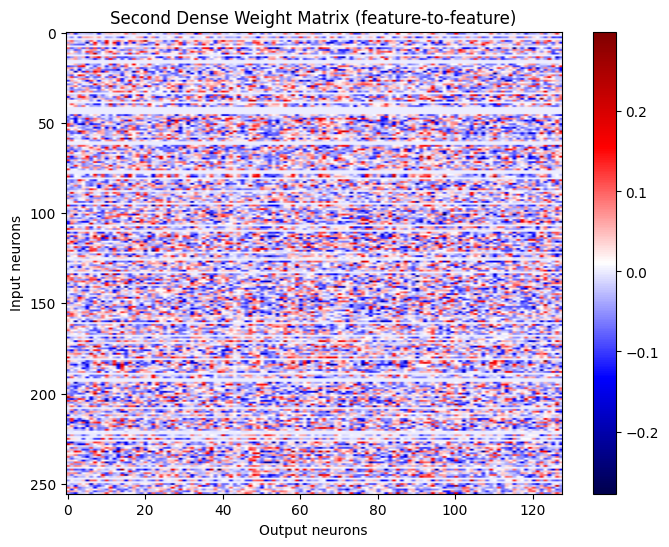

In [16]:
plt.figure(figsize=(8,6))
plt.imshow(W2, aspect='auto', cmap='seismic')
plt.colorbar()
plt.title("Second Dense Weight Matrix (feature-to-feature)")
plt.xlabel("Output neurons")
plt.ylabel("Input neurons")
plt.show()

Each neuron sees abstract features, not pixels.

So weight visualization is no longer spatially meaningful.
The learned features is combined to new features.

In [17]:
#Step 1 — Get Weights
dense_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dense)]

W1, _ = dense_layers[0].get_weights()   # (784, 256)
W2, _ = dense_layers[1].get_weights()   # (256, 128)
W3, _ = dense_layers[2].get_weights()   # (128, 10)

In [19]:
#Step 2 — Compute Effective Pixel Weights for Each Class
# Effective mapping from pixels → class scores
W_effective = W1 @ W2 @ W3   # shape (784, 10)

print(W_effective.shape)

(784, 10)


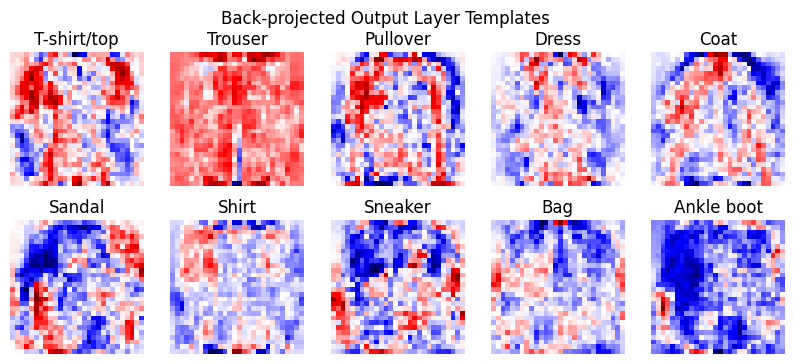

In [20]:
#Step 3 — Visualize

W_img = W_effective.reshape(28, 28, 10)

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(W_img[:,:,i], cmap='seismic')
    plt.title(class_names[i])
    plt.axis("off")

plt.suptitle("Back-projected Output Layer Templates")
plt.show()

## Exercises (in-class or homework)
1. Set `DROPOUT=0` and `L2_WEIGHT=0`. Does val accuracy drop while train rises?
2. Increase `HIDDEN_UNITS` to 512. What happens?
3. Reduce `EPOCHS` to 5. Underfitting or not?
4. Which regularization (dropout vs L2) helps more here?
